# Estudio comparativo de algoritmos en el problema Taxi-v3

*Description*: Implementación y análisis del algoritmo SARSA Semi-gradiente utilizando aproximación de funciones mediante Redes Neuronales Artificiales para resolver el problema LunarLander-v3.

    Authors: Ginés Carrillo Ibáñez, Yago Ibarrola Lapeña, Aarón Palomar Peña
    Emails: gines.carrilloi@um.es, yago.ibarrolal@um.es, aaron.p.p@um.es
    Date: 2026/02/22

## Preparación del entorno


In [1]:
#@title Copiar el repositorio.

#git clone https://github.com/ldaniel-hm/eml_k_bandit.git
#!cd eml_k_bandit/
#@title Importamos todas las clases y funciones

#import sys

# Añadir los directorio fuentes al path de Python
#sys.path.append('/content/eml_k_bandit')


# Verificar que se han añadido correctamente
#print(sys.path)

In [2]:
# @title Instalación e importación de librerías
# !pip install "gymnasium[box2d]" torch numpy matplotlib tqdm

import gymnasium as gym
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

from utils import plot_training_metrics
from agents import SemiGradientSarsaAgent, QNetworkSARSA

import imageio
import base64
from IPython.display import HTML
from collections import deque
# Garantizamos reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## Experimento

El experimento evalúa el rendimiento de un agente que utiliza el algoritmo on-policy SARSA Semi-gradiente para aprender a aterrizar el módulo lunar. Este entorno consta de:
- Espacio de estados: Vector continuo de 8 dimensiones (coordenadas x/y, velocidades x/y, ángulo, velocidad angular, y contacto de las dos patas).
- Espacio de acciones: 4 acciones discretas (0: nada, 1: motor izquierdo, 2: motor principal, 3: motor derecho).
- Recompensa: Recompensas basadas en la distancia a la plataforma, velocidad, inclinación, uso de combustible y un premio/castigo final de +100/-100 por aterrizar o estrellarse. El entorno se considera ``resuelto'' si se alcanzan 200 puntos.

**Objetivo del experimento:**

- Implementar la parametrización de la función de valor de acción $\hat{q}(s, a, \mathbf{w})$ mediante una red neuronal.
- Implementar el bucle de control de SARSA utilizando backpropagation para aproximar el gradiente $\nabla \hat{q}(S, A, \mathbf{w})$.
- Analizar la curva de aprendizaje y la estabilidad del entrenamiento.

## Arquitectura de la Red Neuronal y Política

A diferencia de los métodos tabulares, aquí los pesos $\mathbf{w}$ son los parámetros de la red neuronal.

In [3]:
# @title Bucle de Entrenamiento SARSA Semi-gradiente
def train_sarsa_lunar_lander(agent, episodes=2000):
    scores_window = deque(maxlen=100)  # Cola para calcular la media movil de los ultimos 100
    #rewards_history = []
    env = agent.env
    for t in tqdm(range(episodes)):
        state, info = env.reset(seed=t)  # Reproducibilidad en el estado inicial
        
        action, _ = agent.get_action(state)

        total_reward = 0
        done = False
        
        while not done:
            # # Tomar acción A, observar R, S'
            # action, _ = agent.get_action(state)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            # # Elegir A' desde S' usando la política actual
            # next_action = agent.get_action(next_state)
            
            if not done:
                next_action, _ = agent.get_action(next_state)
            else:
                next_action = None  # no se usará si es terminal
            
            # Actualizar pesos: w <- w + alpha * [R + gamma*q(S',A') - q(S,A)] * grad(q)
            # agent.update(state, action, reward, next_state, next_action, done)
            agent.update(
                obs=state,
                action=action,
                reward=reward, # Incremento de reward respecto al frame anterior
                terminated=done,
                next_obs=next_state,
                next_action=next_action
            )

            state = next_state
            action = next_action
            total_reward += reward
            
        agent.decay_epsilon()
        #rewards_history.append(total_reward)
        scores_window.append(total_reward)
        if t % 100 == 0:
            print(f'\rEpisodio {t}\tMedia ultimos 100: {np.mean(scores_window):.2f}')
        
    env.close() 


In [4]:
n_episodes = 2000
learning_rate = 0.001
start_epsilon = 0.05
epsilon_decay = 0
final_epsilon = 0.05
discount_factor = 0.99


env = gym.make("LunarLander-v3")
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)  # Para obtener estadísticas de episodios   

agent = SemiGradientSarsaAgent(
    env=env,
    learning_rate=learning_rate,
    epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    discount_factor=discount_factor,
)
# Ejecutar el entrenamiento
train_sarsa_lunar_lander(agent, episodes=n_episodes)


c:\Users\aaron\miniconda3\envs\dlpln\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
  0%|          | 1/2000 [00:00<04:48,  6.94it/s]

Episodio 0	Media ultimos 100: -82.53


  5%|▌         | 102/2000 [00:10<02:57, 10.72it/s]

Episodio 100	Media ultimos 100: -198.57


 10%|█         | 201/2000 [01:00<12:55,  2.32it/s]

...

 90%|█████████ | 1801/2000 [15:43<01:35,  2.08it/s]

Episodio 1800	Media ultimos 100: 228.69


 95%|█████████▌| 1901/2000 [17:20<00:28,  3.44it/s]

Episodio 1900	Media ultimos 100: 231.55


100%|██████████| 2000/2000 [18:08<00:00,  1.84it/s]


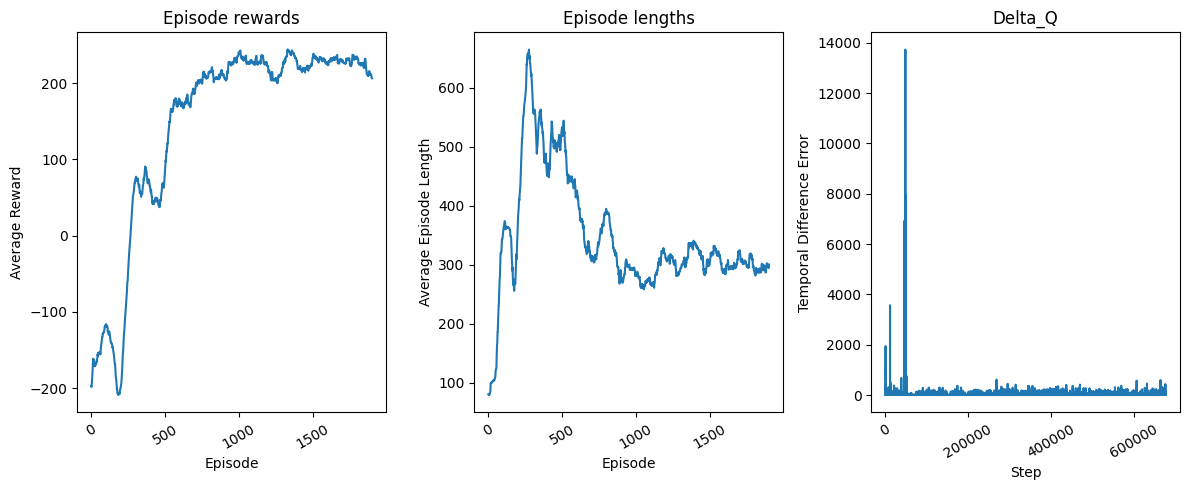

Test Results over 1000 episodes:
Win Rate: 78.0%
Average Reward: 212.480
Standard Deviation: 76.849



In [5]:
plot_training_metrics(env.return_queue, env.length_queue, agent.training_error, rolling_length=100)
agent.test(num_episodes=1000)
print()

In [6]:
n_episodes = 2000
learning_rate = 0.001
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.05
discount_factor = 0.99

env2 = gym.make("LunarLander-v3")
env2 = gym.wrappers.RecordEpisodeStatistics(env2, buffer_length=n_episodes)  # Para obtener estadísticas de episodios   

agent2 = SemiGradientSarsaAgent(
    env=env2,
    learning_rate=learning_rate,
    epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    discount_factor=discount_factor,
)
# Ejecutar el entrenamiento
train_sarsa_lunar_lander(agent2, episodes=n_episodes)


  0%|          | 0/2000 [00:00<?, ?it/s]

Episodio 0	Media ultimos 100: -134.58


  5%|▌         | 101/2000 [00:19<04:17,  7.39it/s]

Episodio 100	Media ultimos 100: -169.26


 10%|█         | 201/2000 [00:33<05:08,  5.84it/s]

...

 90%|█████████ | 1801/2000 [28:20<04:35,  1.39s/it]

Episodio 1800	Media ultimos 100: 213.58


 95%|█████████▌| 1901/2000 [30:29<01:49,  1.11s/it]

Episodio 1900	Media ultimos 100: 226.73


100%|██████████| 2000/2000 [32:24<00:00,  1.03it/s]


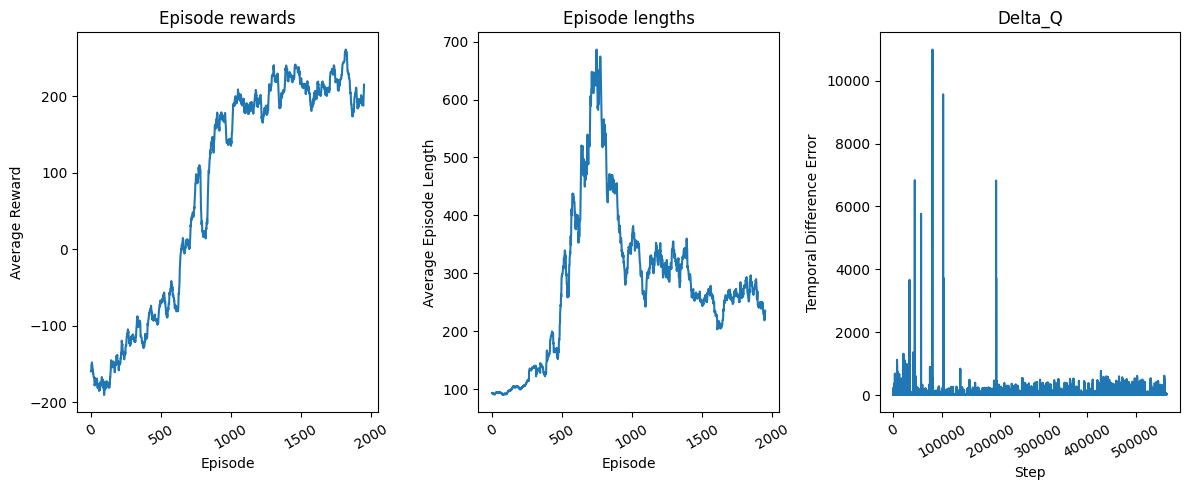

Test Results over 1000 episodes:
Win Rate: 52.9%
Average Reward: 153.235
Standard Deviation: 107.049



In [7]:
plot_training_metrics(env2.return_queue, env2.length_queue, agent2.training_error, rolling_length=50)
agent2.test(num_episodes=1000)
print()

In [8]:
n_episodes = 2000
learning_rate = 0.01
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.05
discount_factor = 0.99

env3 = gym.make("LunarLander-v3")
env3 = gym.wrappers.RecordEpisodeStatistics(env3, buffer_length=n_episodes)  # Para obtener estadísticas de episodios   

agent3 = SemiGradientSarsaAgent(
    env=env3,
    learning_rate=learning_rate,
    epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    discount_factor=discount_factor,
)
# Ejecutar el entrenamiento
train_sarsa_lunar_lander(agent3, episodes=n_episodes)


  0%|          | 0/2000 [00:00<?, ?it/s]

Episodio 0	Media ultimos 100: -134.58

  0%|          | 1/2000 [00:00<05:11,  6.41it/s]

  5%|▌         | 103/2000 [00:20<03:57,  8.00it/s]

Episodio 100	Media ultimos 100: -166.93


...

 90%|█████████ | 1801/2000 [22:13<02:29,  1.33it/s]

Episodio 1800	Media ultimos 100: -110.04


 95%|█████████▌| 1901/2000 [24:41<06:13,  3.78s/it]

Episodio 1900	Media ultimos 100: -118.70


100%|██████████| 2000/2000 [27:48<00:00,  1.20it/s]


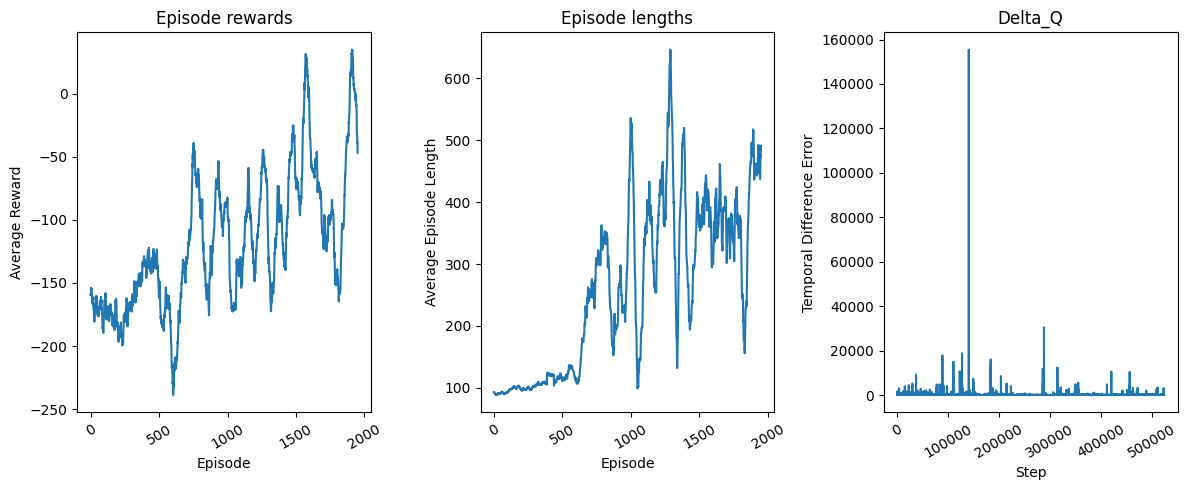

Test Results over 1000 episodes:
Win Rate: 0.0%
Average Reward: -292.405
Standard Deviation: 40.522



In [9]:
plot_training_metrics(env3.return_queue, env3.length_queue, agent3.training_error, rolling_length=50)
agent3.test(num_episodes=1000)
print()

In [10]:
n_episodes = 2000
learning_rate = 0.001
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.05
discount_factor = 0.99

env4 = gym.make("LunarLander-v3")
env4 = gym.wrappers.RecordEpisodeStatistics(env4, buffer_length=n_episodes)  # Para obtener estadísticas de episodios   

agent4 = SemiGradientSarsaAgent(
    env=env4,
    learning_rate=learning_rate,
    epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    discount_factor=discount_factor,
    hidden_dim=64,
)
# Ejecutar el entrenamiento
train_sarsa_lunar_lander(agent4, episodes=n_episodes)


  0%|          | 0/2000 [00:00<?, ?it/s]

Episodio 0	Media ultimos 100: -134.58


  5%|▌         | 103/2000 [00:15<03:43,  8.51it/s]

Episodio 100	Media ultimos 100: -163.69


 10%|█         | 201/2000 [00:30<06:12,  4.82it/s]

...

 90%|█████████ | 1801/2000 [19:15<05:18,  1.60s/it]

Episodio 1800	Media ultimos 100: 193.42


 95%|█████████▌| 1901/2000 [20:12<00:35,  2.80it/s]

Episodio 1900	Media ultimos 100: 228.44


100%|██████████| 2000/2000 [21:12<00:00,  1.57it/s]


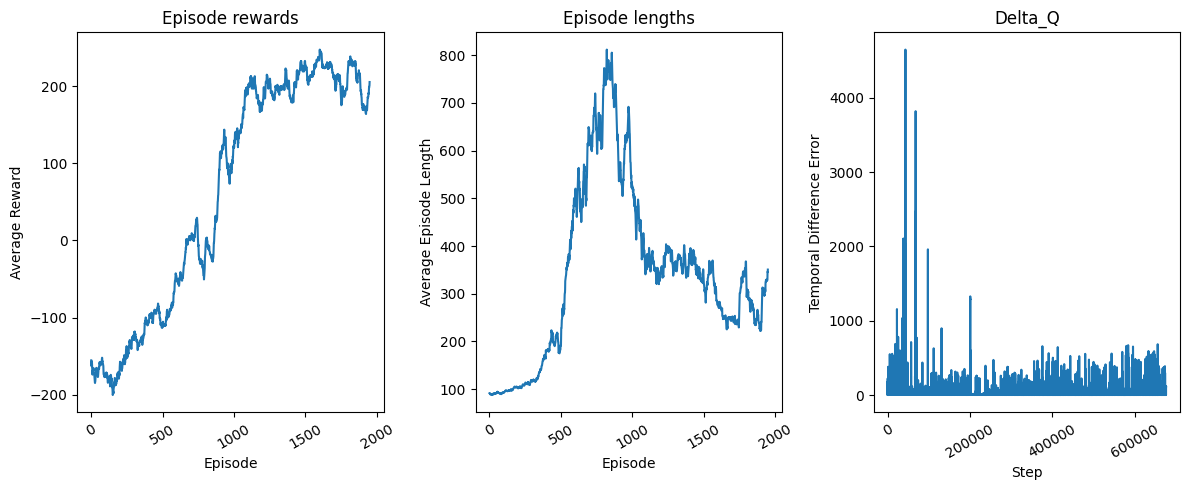

Test Results over 1000 episodes:
Win Rate: 28.4%
Average Reward: 54.447
Standard Deviation: 140.463



In [11]:
plot_training_metrics(env4.return_queue, env4.length_queue, agent4.training_error, rolling_length=50)
agent4.test(num_episodes=1000)
print()

## Análisis de Resultados y Conclusiones

- Recompensa promedio por episodio: Al inicio, el agente obtendrá puntuaciones cercanas a -200 o -300, ya que los motores se activan aleatoriamente y el módulo se estrella rápidamente o sale de la pantalla. 
- A medida que $\epsilon$ decae y los pesos $\mathbf{w}$ se ajustan, la recompensa media aumenta.
- La inestabilidad (gráficas de recompensa que suben a 100 y de repente caen en picado) es una característica de usar Redes Neuronales con métodos on-line como SARSA.
- Las muestras sucesivas $(S, A, R, S')$ están altamente correlacionadas, lo que hace que la red neuronal "olvide" lo aprendido en zonas anteriores del espacio de estados.
- Mientras que en problemas tabulares SARSA y Q-Learning convergen con garantías teóricas, al introducir Redes Neuronales el control del hiperparámetro de tasa de aprendizaje ($\alpha$) y la arquitectura de la red determinan la convergencia. 
- Una mejora es usar DQN (Deep Q-Networks), que añade un "Buffer de Repetición" para romper la correlación y una "Red Objetivo" (Target Network) para estabilizar el gradiente.

In [12]:
# Guardar pesos del modelo entrenado
torch.save(agent2.q_network.state_dict(), "results/SARSADeepLunarLander/sarsa_lunarlander_qnetwork4.pth")
print("Pesos guardados correctamente.")

Pesos guardados correctamente.


Código sacado de https://github.com/ldaniel-hm/eml_approximate/blob/0730b02e2a973683f400f71d60e92ac24a403d55/SolucionDeepSARSA_CartPole.ipynb#L345

In [13]:
def greedy_action(q_network, state):
    """
    Selecciona la acción óptima (greedy) para un estado dado utilizando la red Q.

    Parámetros:
      - q_network (QNetwork): Red neuronal con los pesos cargados.
      - state: Estado actual del entorno (puede ser una lista o tensor).

    Retorna:
      - int: Acción que maximiza Q(s,a).
    """
    # Desactivamos el cálculo de gradientes (no es necesario en modo evaluación).
    with torch.no_grad():
        # Convertir el estado a tensor si no lo es y añadir dimensión de batch.
        if not isinstance(state, torch.Tensor):
            state = torch.FloatTensor(state).unsqueeze(0)
        # Calcular los valores Q para el estado.
        q_values = q_network(state)
        # Seleccionar la acción que maximiza Q(s,a).
        action = torch.argmax(q_values).item()
    return action

def run_episode_greedy_lunarlander(env, q_network, max_steps=500):
    """
    Ejecuta un episodio usando la política greedy y captura los fotogramas.

    Parámetros:
      - env: Entorno Gymnasium configurado con render_mode='rgb_array'.
      - q_network: Red neuronal QNetwork con los pesos cargados.
      - max_steps (int): Número máximo de pasos a ejecutar en el episodio.

    Retorna:
      - list: Lista de fotogramas (imágenes) capturados durante el episodio.
    """
    frames = []  # Lista para almacenar cada fotograma.

    # Reiniciar el entorno y obtener el estado inicial.
    state, _ = env.reset()
    done = False  # Indicador de finalización del episodio.

    # Ejecutar el episodio hasta max_steps o hasta que el entorno indique que ha terminado.
    for _ in range(max_steps):
        # Capturar el fotograma actual del entorno.
        frame = env.render()
        frames.append(frame)

        # Seleccionar la acción óptima utilizando la función greedy.
        action = greedy_action(q_network, state)

        # Ejecutar la acción en el entorno y obtener el siguiente estado y otros datos.
        next_state, reward, done, truncated, info = env.step(action)
        state = next_state  # Actualizar el estado.

        # Si el episodio ha terminado o se ha truncado, capturar el fotograma final y salir.
        if done or truncated:
            frames.append(env.render())
            break

    return frames

def frames_to_gif(frames, filename="results/SARSADeepLunarLander/lunarlander_sarsa.gif"):
    """
    Crea un archivo GIF a partir de una lista de fotogramas.

    Parámetros:
      - frames (list): Lista de fotogramas (imágenes) capturados del entorno.
      - filename (str): Nombre del archivo GIF resultante.

    Retorna:
      - str: Nombre del archivo GIF creado.
    """
    # Abrir un escritor de GIF con imageio.
    with imageio.get_writer(filename, mode='I') as writer:
        # Agregar cada fotograma al GIF.
        for frame in frames:
            writer.append_data(frame)
    return filename
     

def display_gif(gif_path):
    """
    Muestra un GIF en Google Colab.

    Parámetros:
      - gif_path (str): Ruta del archivo GIF.

    Retorna:
      - HTML: Objeto HTML que contiene el GIF incrustado.
    """
    # Abrir el archivo GIF en modo binario.
    with open(gif_path, 'rb') as f:
        video = f.read()
    # Convertir el contenido del GIF a una cadena Base64.
    b64 = base64.b64encode(video)
    # Retornar el objeto HTML que muestra el GIF.
    return HTML(f'<img src="data:image/gif;base64,{b64.decode()}" />')

GIF guardado en: results/SARSADeepLunarLander/lunarlander_sarsa.gif



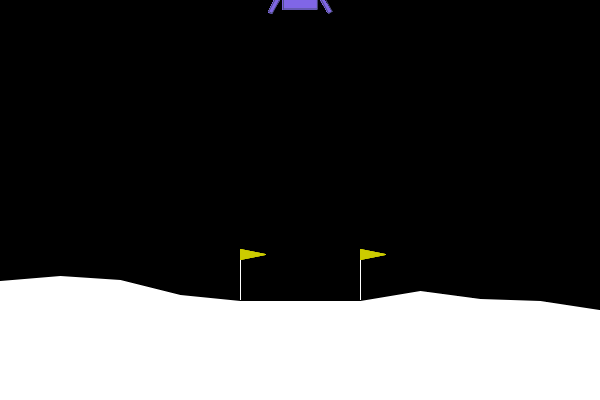

In [14]:
# Crear entorno con modo render para capturar imágenes
env_demo = gym.make("LunarLander-v3", render_mode='rgb_array')

state_dim = env_demo.observation_space.shape[0]
action_dim = env_demo.action_space.n

# Crear una instancia de la red QNetwork.
q_net_loaded = QNetworkSARSA(state_dim, action_dim, hidden_dim=128)

# Cargar pesos
q_net_loaded.load_state_dict(torch.load("results/SARSADeepLunarLander/sarsa_lunarlander_qnetwork.pth"))

# Poner la red en modo evaluación para asegurar que se comporta correctamente en inferencia.
q_net_loaded.eval()

# Ejecutar un episodio utilizando la política greedy y capturar los fotogramas.
frames = run_episode_greedy_lunarlander(env_demo, q_net_loaded)

# Cerrar el entorno una vez terminado el episodio.
env_demo.close()

# Crear el GIF a partir de los fotogramas capturados.
gif_path = frames_to_gif(frames, filename="results/SARSADeepLunarLander/lunarlander_sarsa.gif")
print("GIF guardado en:", gif_path)

# Mostrar GIF
display_gif(gif_path)